# Food Truck

Here we will implement linear regression with one variable to predict profits for a food truck.  <br>


Suppose you are the CEO of a restaurant franchise and are considering different cities for opening a new outlet. The chain already has trucks in various cities and you have data for profits and populations from the cities. <br>


The file food_truck.txt  contains the dataset for our linear regression exercise.  <br>


The first column is the population of a city and the second column is the profit of a food truck in that city. A negative value for profit indicates a loss. <br>


So. let's start. <br>

## Importing Libraries

In [1]:
# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing the dataset

In [2]:
data = pd.read_csv(r'..\food_truck.txt', header = None, delimiter = ",") #read from dataset
X = data.iloc[:,0] # read first column, will be put in a 'series' variable
print('X.shape: ', X.shape)
y = data.iloc[:,1] # read second column, will be put in a 'series' variable
print('y.shape: ', y.shape)
m = len(y) # number of training example (97)
print('Number of samples:', m)
print(data.head()) # view first few rows of the data

X.shape:  (97,)
y.shape:  (97,)
Number of samples: 97
        0        1
0  6.1101  17.5920
1  5.5277   9.1302
2  8.5186  13.6620
3  7.0032  11.8540
4  5.8598   6.8233


## Visualization of the data

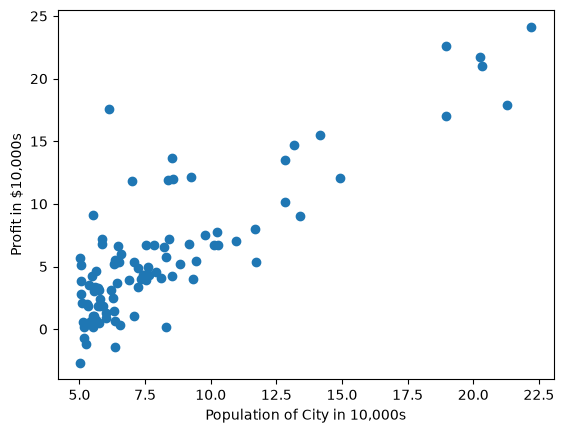

In [3]:
# FEEL FREE TO IMPROVE THE PLOT

# Reading and Plotting the data
# Before starting on any task, try to visualize the data. 
# You can use a scatter plot to visualize this data, since it has only two properties to plot (profit and population).
# For multidimensional data : cannot be plotted on a 2-d or 3-d plot. 

plt.scatter(X, y)
plt.xlabel('Population of City in 10,000s')
plt.ylabel('Profit in $10,000s')
plt.show()

Initializing and converting into an nparray, we want to make use of array manipulations (dot product). <br>

In the following lines, we add another dimension to our data to accommodate the intercept term, we want to find the best values for Theta0 and Theta1 for the function:  <br>

**y = Theta0 + Theta1 * x** <br> 

by getting the error/cost as small as possible.  <br>


We also initialize the initial parameters theta to 0 and the learning rate alpha to 0.01. <br>

## Reshaping the data

In [4]:
print(type(X)) # should be a pd.Series()
X = X.to_numpy()[:,np.newaxis] # convert pd.Series() to an np.ndarray
y = y.to_numpy()[:,np.newaxis] # convert pd.Series() to an np.ndarray

# Will generate a warning:
# Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.

# # Better w/o warning
# X = X.to_numpy()[:,np.newaxis] # convert pd.Series() to an np.ndarray
# y = y.to_numpy()[:,np.newaxis] # convert pd.Series() to an np.ndarray
X_ones = np.ones((m,1))
X = np.hstack((X_ones, X))
theta = np.zeros([2,1]) # start off with a (0, 0) array
iterations = 100000 # 
learning_rate = 0.01 # magic number, defines the increase in change in Theta in every iteration we take

# apply the trick we saw in the classroom of 'all ones' for x0, so that we can use matrix multiplication
# TAKE CARE WITH THE VARIABLE NAMES 

<class 'pandas.Series'>


## Computting the cost (or error)

In [5]:
def computeCost(X_ones, y, theta):
    # We are going to calculate the MSE (Mean Square Error). NOT the RMSE (Root Mean Square Error)
    #
    # FILL IN THE NECESSARY CODE. Return the cost.
    cost = np.dot(X, theta) - y
    total_cost = np.sum(np.power(cost, 2)) / (m*2)
    return total_cost

In [6]:
# What is the initial error/cost with the current theta0 and theta1 values = 0?
cost = computeCost(X_ones, y, theta)
print(cost)
# You get a cost of 32.072733877455676

32.072733877455676


## Creating the Optimizer

In [7]:
def gradientDescent(X, y, theta, this_learning_rate, this_iterations):
    print(f"learning rate={this_learning_rate} and iterations={this_iterations}")
    new_theta = theta.copy()
    # First work out what the partial derivatives are, then apply the gradientDescent 
    # Parameters:
    # -----------
    # X: matrix with the input variables
    # y: the correct results
    # iterations: The number of times the gradientDescent should run.
    #
    # FILL IN THE NECESSARY CODE.
    # After the iterations are performed, return the theta0 and theta1 values.
    for _ in range(this_iterations):
        iterat = X.dot(new_theta)
        error = iterat - y

        gradient = 2*X.T.dot(error)/len(X)
        new_theta -= this_learning_rate * gradient
        
    return new_theta

In [8]:
theta_refined = gradientDescent(X, y, theta, learning_rate, iterations)
print(theta_refined)
###  This should result in
#  [[-3.89578088]
#  [ 1.19303364]]
### 

learning rate=0.01 and iterations=100000
[[-3.89578088]
 [ 1.19303364]]


## Checking the final cost (or error)

In [9]:
cost_refined =  computeCost(X, y, theta_refined)
print(cost_refined)

4.476971375975179


In [10]:
# Can we improve on these results?
# Try with different values for the number of iterations and with different learning rates
# Try eg with as number of iterations: 500, 1500, 5000, 10000, 100000,...
# Try a different learning rate: 0.1, 0.03, 0.01, 0.003, 0.001, ...
iterations_test1 = 600
learning_rate_test1 = 0.001
theta_refined_test1 = gradientDescent(X, y, theta, learning_rate_test1, iterations_test1)
print(theta_refined_test1)
cost_refined_test1 =  computeCost(X, y, theta_refined_test1)
print(cost_refined_test1)

iterations_test2 = 30000
learning_rate_test2 = 0.005
theta_refined_test2 = gradientDescent(X, y, theta, learning_rate_test2, iterations_test2)
print(theta_refined_test2)
cost_refined_test2 =  computeCost(X, y, theta_refined_test2)
print(cost_refined_test2)

iterations_test3 = 55000
learning_rate_test3 = 0.005
theta_refined_test3 = gradientDescent(X, y, theta, learning_rate_test3, iterations_test3)
print(theta_refined_test3)
cost_refined_test3 =  computeCost(X, y, theta_refined_test3)
print(cost_refined_test3)

learning rate=0.001 and iterations=600
[[-0.69369331]
 [ 0.87134922]]
5.4104317096928485
learning rate=0.005 and iterations=30000
[[-3.89578088]
 [ 1.19303364]]
4.476971375975179
learning rate=0.005 and iterations=55000
[[-3.89578088]
 [ 1.19303364]]
4.476971375975179


Cost with 500    iterations : 4.713809531116866 <br>
Cost with 1000   iterations : 4.515955503078912 <br>
Cost with 1500   iterations : 4.483388256587726 <br>
Cost with 10000  iterations : 4.476971375975179 <br>
Cost with 100000 iterations : 4.476971375975179 <br>

## Vizualization of the Linear Regression

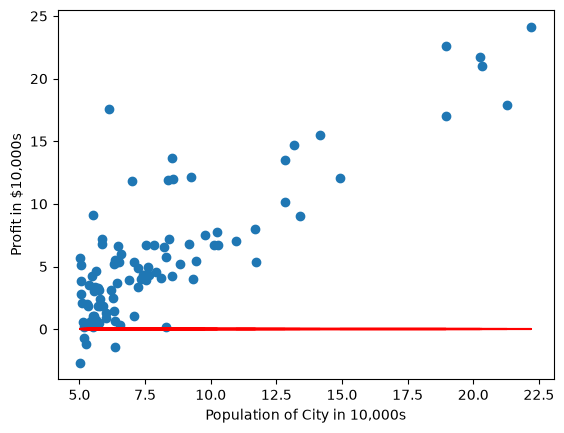

In [11]:
plt.scatter(X[:,1], y)
plt.xlabel('Population of City in 10,000s')
plt.ylabel('Profit in $10,000s')
plt.plot(X[:,1], np.dot(X, theta), color = 'red')
plt.show()

## Predicting

Make some predictions

## --------------------------------------------------------------------------

## Linear Regression with Scikit-Learn

As you already worked with Scikit-Learn. Apply the Linear regression from the Scikit-Learn and check if the results are the same.
Are they? If no, why?

